In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')

In [9]:
BASE = "/content/northstar_dataset/"

orders = pd.read_csv(BASE + "orders.csv")
deliveries = pd.read_csv(BASE + "deliveries.csv")
customers = pd.read_csv(BASE + "customers.csv")
drivers = pd.read_csv(BASE + "drivers.csv")
vehicles = pd.read_csv(BASE + "vehicles.csv")
hubs = pd.read_csv(BASE + "hubs.csv")
incidents = pd.read_csv(BASE + "incidents.csv")
complaints = pd.read_csv(BASE + "complaints.csv")
app_events = pd.read_csv(BASE + "app_events.csv")

# Display sample data
print(deliveries.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time       delivery_completed_at delivery_status  route_distance_km  manual_route_override_count  proof_of_completion_missing  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00  2024-06-19 09:05:59.904311          Failed              17.26                            1                            0   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00  2025-01-11 17:39:00.000000          OnTime              10.34                            1                            0   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00  2025-06-02 21:45:32.366770          OnTime               7.92                            0                            0   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00  2024-03-09 23:30:08.103702         Delayed              16.42                            0                            0   
4     DL00005   O008

In [11]:
# DATA CLEANING
# 1. STANDARDISE ZONE NAMES

def clean_zone(series):
    return series.str.strip().str.title()

orders['pickup_zone'] = clean_zone(
    orders['pickup_zone']
)

orders['dropoff_zone'] = clean_zone(
    orders['dropoff_zone']
)

customers['home_zone'] = clean_zone(
    customers['home_zone']
)

drivers['base_zone'] = clean_zone(
    drivers['base_zone']
)

vehicles['assigned_zone'] = clean_zone(
    vehicles['assigned_zone']
)

app_events['zone_context'] = clean_zone(
    app_events['zone_context']
)

# 2. CONVERT DATE COLUMNS

orders['order_created_at'] = pd.to_datetime(
    orders['order_created_at'],
    errors='coerce'
)

deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'],
    errors='coerce'
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'],
    errors='coerce'
)

complaints['created_at'] = pd.to_datetime(
    complaints['created_at'],
    errors='coerce'
)

# 3. FEATURE ENGINEERING

#--- Delivery duration---

deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at']
    - deliveries['dispatch_time']
).dt.total_seconds() / 3600

#--- Negative duration flag---

deliveries['is_anomalous_time'] = (
    deliveries['delivery_duration_hrs'] < 0
)

#--- Cost per km---

deliveries['cost_per_km'] = (
    deliveries['fuel_or_charge_cost']
    / deliveries['route_distance_km']
)

#--- Complaint month ---

complaints['complaint_month'] = (
    complaints['created_at'].dt.to_period('M')
)

print("Data Cleaning Complete")

Data Cleaning Complete


                               orders  deliveries  customers  drivers  vehicles  incidents  complaints  app_events
battery_health_pct                  0           0          0        0         4          0           0           0
booking_channel                    25           0          0        0         0          0           0           0
compensation_amount                 0           0          0        0         0          0          16           0
customer_rating_post_delivery       0          14          0        0         0          0           0           0
delivery_completed_at               0          19          0        0         0          0           0           0
delivery_duration_hrs               0          19          0        0         0          0           0           0
loyalty_score                       0           0         20        0         0          0           0           0
order_id                            0           0          0        0         0 

<Figure size 1200x600 with 0 Axes>

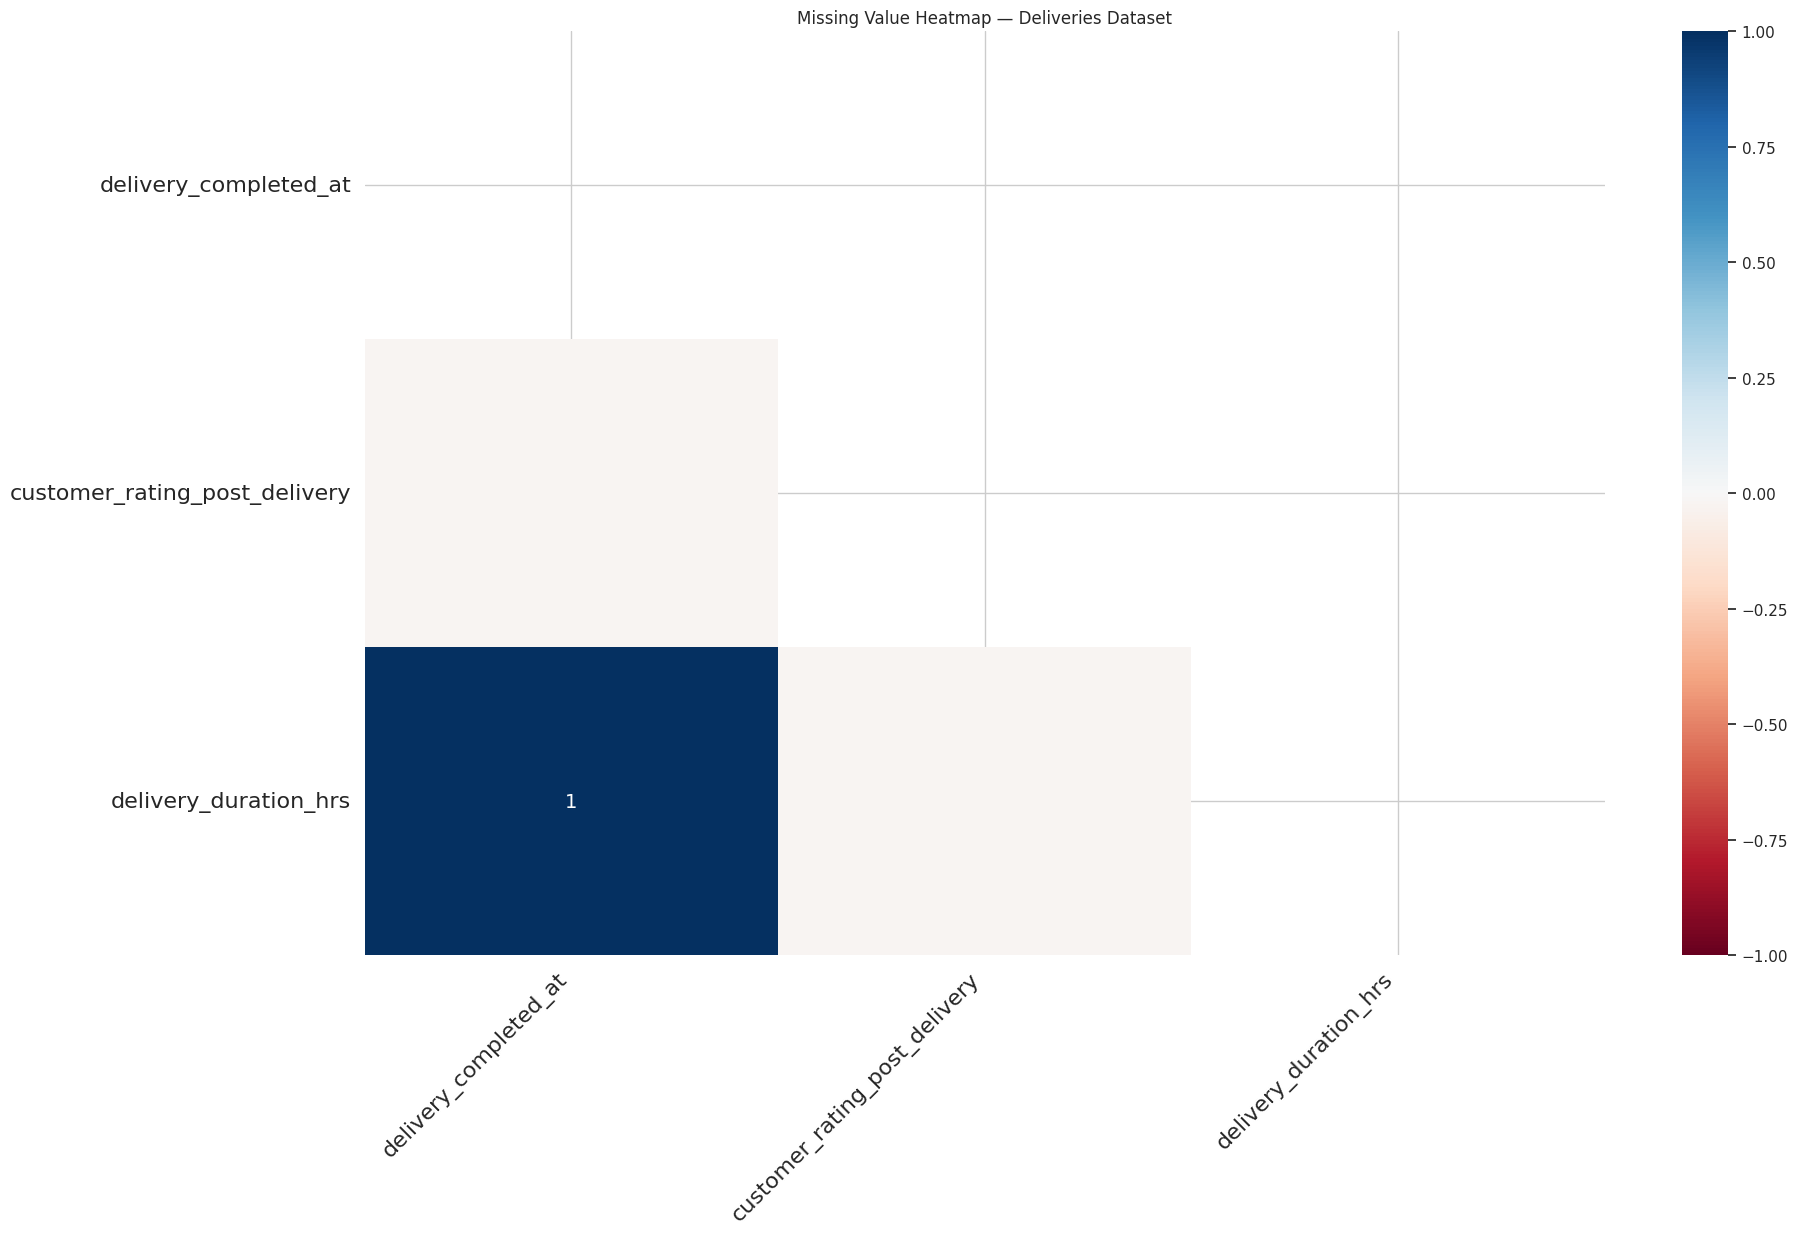

In [12]:
# MISSING VALUE ANALYSIS
datasets = {
    'orders': orders,
    'deliveries': deliveries,
    'customers': customers,
    'drivers': drivers,
    'vehicles': vehicles,
    'incidents': incidents,
    'complaints': complaints,
    'app_events': app_events
}

missing_summary = pd.DataFrame({
    name: df.isnull().sum()
    for name, df in datasets.items()
}).fillna(0).astype(int)

print(missing_summary[
    missing_summary.sum(axis=1) > 0
])

#--- Missing Value Heat map ---
plt.figure(figsize=(12,6))
msno.heatmap(deliveries)
plt.title("Missing Value Heatmap — Deliveries Dataset")
plt.show()



  hub_id        hub_name       zone  total  failed  late  avg_rating  failure_rate
7    H08   Midtown Relay    Central    128      26     0    3.884560     20.312500
4    H05    Central Core    Central    115      23     0    3.669558     20.000000
5    H06     Airport Hub    Airport    104      15     0    3.882136     14.423077
3    H04       West Gate       West    127      16     0    3.915476     12.598425
0    H01  North Exchange      North    136      17     0    3.840593     12.500000
6    H07   Riverside Hub  Riverside    115      14     0    3.881858     12.173913
1    H02      South Link      South    106      10     0    3.950952      9.433962
2    H03       East Dock       East    119      11     0    3.895862      9.243697


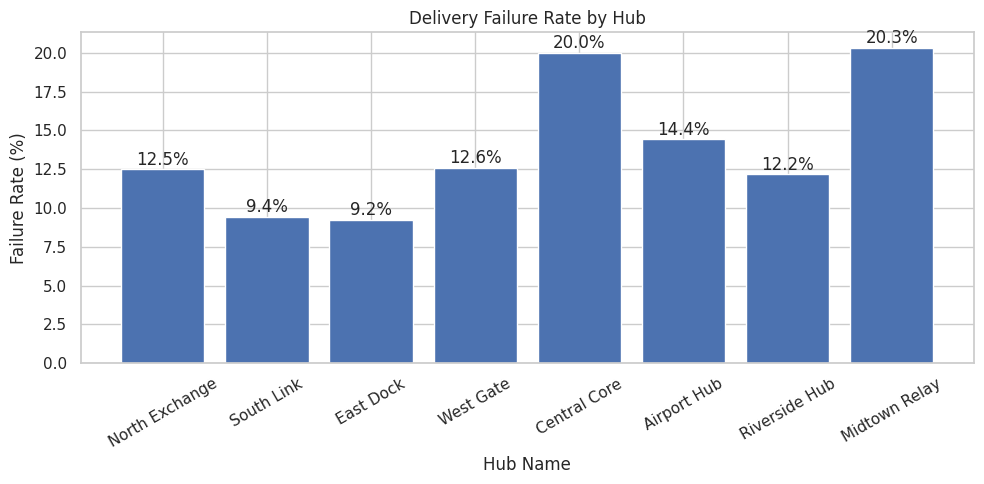


INTERPRETATION:
Hubs with high failure rates indicate operational inefficiencies,
dispatch problems, or resource shortages.



In [14]:
#  ANALYSIS 1 — DELIVERY FAILURE RATE BY HUB

del_hub = deliveries.merge(
    hubs,
    on='hub_id',
    how='left'
)

hub_perf = del_hub.groupby(
    ['hub_id','hub_name','zone']
).agg(
    total=('delivery_id','count'),
    failed=(
        'delivery_status',
        lambda x: (x == 'Failed').sum()
    ),
    late=(
        'delivery_status',
        lambda x: (x == 'Late').sum()
    ),
    avg_rating=(
        'customer_rating_post_delivery',
        'mean'
    )
).reset_index()

hub_perf['failure_rate'] = (
    hub_perf['failed']
    / hub_perf['total']
) * 100

print(
    hub_perf.sort_values(
        'failure_rate',
        ascending=False
    )
)


# ---CHART — HUB FAILURE RATE---

plt.figure(figsize=(10,5))

bars = plt.bar(
    hub_perf['hub_name'],
    hub_perf['failure_rate']
)

plt.title("Delivery Failure Rate by Hub")

plt.xlabel("Hub Name")

plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()

plt.show()

print("""
INTERPRETATION:
Hubs with high failure rates indicate operational inefficiencies,
dispatch problems, or resource shortages.
""")


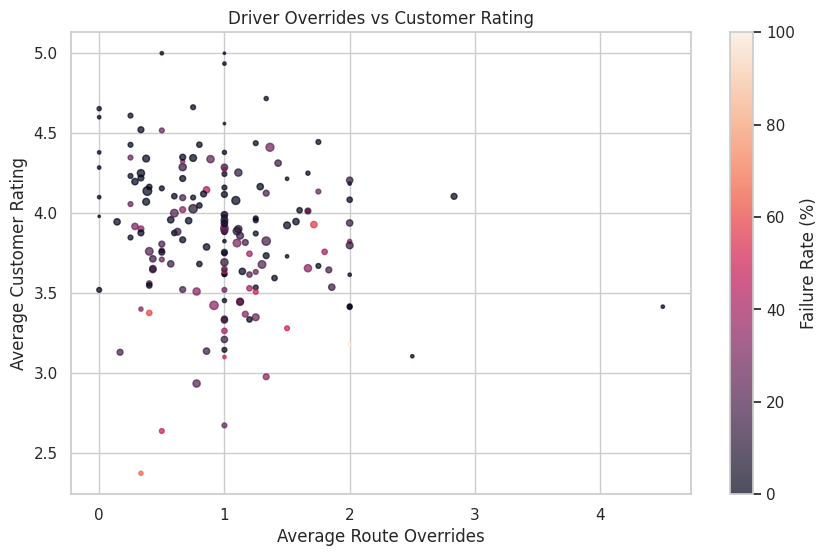


INTERPRETATION:
Drivers with excessive overrides may experience lower customer
ratings and higher delivery failure rates.



In [15]:
# ANALYSIS 2 — DRIVER OVERRIDES VS CUSTOMER RATING

del_drv = deliveries.merge(
    drivers,
    on='driver_id',
    how='left'
)

drv_perf = del_drv.groupby(
    'driver_id'
).agg(
    total_deliveries=('delivery_id','count'),

    avg_overrides=(
        'manual_route_override_count',
        'mean'
    ),

    avg_rating=(
        'customer_rating_post_delivery',
        'mean'
    ),

    failure_rate=(
        'delivery_status',
        lambda x: (x == 'Failed').mean()*100
    )
).reset_index()


# ---SCATTER PLOT---
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    drv_perf['avg_overrides'],
    drv_perf['avg_rating'],
    c=drv_perf['failure_rate'],
    s=drv_perf['total_deliveries']*3,
    alpha=0.7
)

plt.colorbar(scatter,
             label='Failure Rate (%)')

plt.title(
    "Driver Overrides vs Customer Rating"
)

plt.xlabel(
    "Average Route Overrides"
)

plt.ylabel(
    "Average Customer Rating"
)
plt.show()

print("""
INTERPRETATION:
Drivers with excessive overrides may experience lower customer
ratings and higher delivery failure rates.
""")


      complaint_type  count  avg_resolution_days  avg_compensation   pct_open
0           AppIssue     53             8.603774         19.614400  15.094340
1            Billing     16             7.750000         23.871250  31.250000
2             Damage     15            11.333333         23.982000   6.666667
3              Delay    101             7.257426         18.051489  16.831683
4    DriverBehaviour     51             8.156863         21.153478  17.647059
5       MissedPickup     64             7.640625         22.593651  18.750000
6  SupportExperience     20             7.450000         17.125000  20.000000


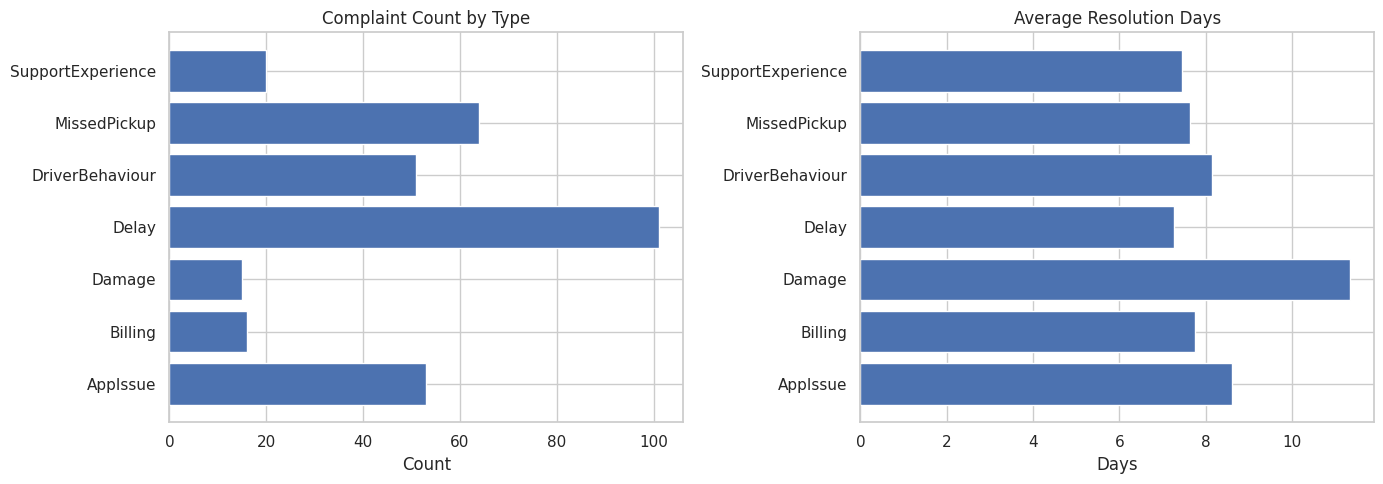


INTERPRETATION:
Complaint categories with longer resolution periods may indicate
poor customer service efficiency and operational delays.



In [16]:
# ANALYSIS 3 — COMPLAINT ANALYSIS

comp_type = complaints.groupby(
    'complaint_type'
).agg(
    count=('complaint_id','count'),

    avg_resolution_days=(
        'resolution_days',
        'mean'
    ),

    avg_compensation=(
        'compensation_amount',
        'mean'
    ),

    pct_open=(
        'status',
        lambda x: (x == 'Open').mean()*100
    )

).reset_index()

print(comp_type)

# ---Bar Chart---

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

axes[0].barh(
    comp_type['complaint_type'],
    comp_type['count']
)

axes[0].set_title(
    "Complaint Count by Type"
)

axes[0].set_xlabel("Count")

axes[1].barh(
    comp_type['complaint_type'],
    comp_type['avg_resolution_days']
)

axes[1].set_title(
    "Average Resolution Days"
)

axes[1].set_xlabel("Days")

plt.tight_layout()

plt.show()

print("""
INTERPRETATION:
Complaint categories with longer resolution periods may indicate
poor customer service efficiency and operational delays.
""")



  maintenance_status  total_deliveries  incident_count  avg_battery  avg_resolved_hrs  incident_rate
0             Active               554             150    76.395265         11.585211      27.075812
1           InRepair               268              84    76.406716         12.784810      31.343284
2          Scheduled               160              46    78.696250         11.997619      28.750000


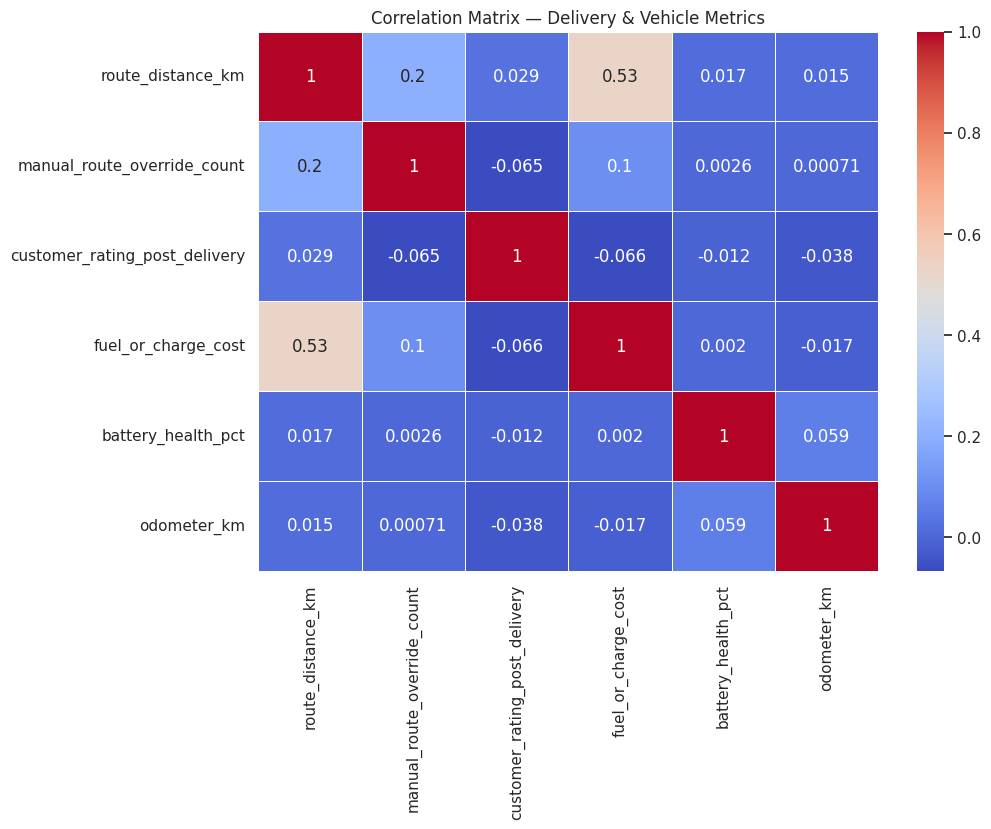


INTERPRETATION:
Strong correlations between fuel costs, route distance,
and battery health reveal important operational relationships.



In [17]:
#  ANALYSIS 4 — VEHICLE INCIDENT CORRELATION

del_veh = deliveries.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

del_veh_inc = del_veh.merge(
    incidents,
    on='delivery_id',
    how='left'
)

maint_inc = del_veh_inc.groupby(
    'maintenance_status'
).agg(
    total_deliveries=('delivery_id','count'),

    incident_count=(
        'incident_id',
        lambda x: x.notna().sum()
    ),

    avg_battery=(
        'battery_health_pct',
        'mean'
    ),

    avg_resolved_hrs=(
        'resolved_hours',
        'mean'
    )

).reset_index()

maint_inc['incident_rate'] = (
    maint_inc['incident_count']
    / maint_inc['total_deliveries']
) * 100

print(maint_inc)

# ---CORRELATION HEATMAP---
numeric_cols = del_veh[[
    'route_distance_km',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'fuel_or_charge_cost',
    'battery_health_pct',
    'odometer_km'
]].dropna()

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    "Correlation Matrix — Delivery & Vehicle Metrics"
)

plt.show()

print("""
INTERPRETATION:
Strong correlations between fuel costs, route distance,
and battery health reveal important operational relationships.
""")


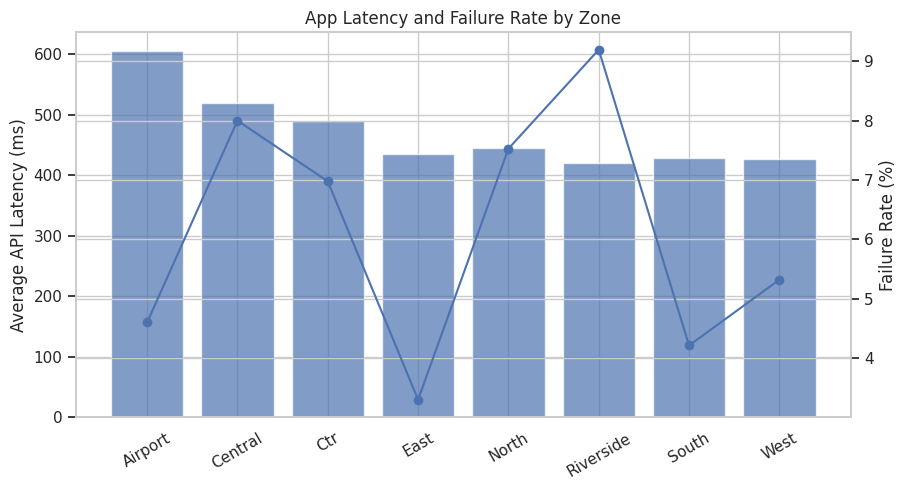


INTERPRETATION:
Zones with higher API latency often experience higher app
failure rates, affecting customer digital experience.



In [18]:
# ANALYSIS 5 — APP LATENCY AND FAILURE RATE

app_zone = app_events.groupby(
    'zone_context'
).agg(
    total_events=('event_id','count'),

    success_rate=(
        'success_flag',
        'mean'
    ),

    avg_latency=(
        'api_latency_ms',
        'mean'
    ),

    p95_latency=(
        'api_latency_ms',
        lambda x: np.percentile(x,95)
    )

).reset_index()

app_zone['failure_rate'] = (
    1 - app_zone['success_rate']
) * 100


# ---DUAL AXIS CHART---
fig, ax1 = plt.subplots(
    figsize=(10,5)
)

ax2 = ax1.twinx()

x = range(len(app_zone))

ax1.bar(
    x,
    app_zone['avg_latency'],
    alpha=0.7
)

ax2.plot(
    x,
    app_zone['failure_rate'],
    marker='o'
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    app_zone['zone_context'],
    rotation=30
)

ax1.set_ylabel(
    "Average API Latency (ms)"
)

ax2.set_ylabel(
    "Failure Rate (%)"
)

plt.title(
    "App Latency and Failure Rate by Zone"
)

plt.show()

print("""
INTERPRETATION:
Zones with higher API latency often experience higher app
failure rates, affecting customer digital experience.
""")



In [19]:
# FINAL SUMMARY

print("""
KEY FINDINGS

1. Several hubs experience high delivery failure rates.
2. Driver overrides negatively affect customer satisfaction.
3. Complaint resolution delays indicate operational inefficiencies.
4. Vehicle maintenance issues correlate with incident rates.
5. API latency impacts customer platform performance.
""")


KEY FINDINGS

1. Several hubs experience high delivery failure rates.
2. Driver overrides negatively affect customer satisfaction.
3. Complaint resolution delays indicate operational inefficiencies.
4. Vehicle maintenance issues correlate with incident rates.
5. API latency impacts customer platform performance.

